# Assignment 4 — Logistic Regression

## Industry problem statement 1
An acquisition team wants to predict whether a prospect will respond to a campaign so outreach can be prioritised.

## Industry problem statement 2
A risk team wants to classify whether a customer belongs to a target risk/response category while retaining interpretable coefficients.

## Intuitive understanding
Think of logistic regression as a probability-based yes/no gate. It estimates the probability of belonging to a class and converts that probability into a decision threshold.

## What are we trying to answer?
Can we predict the required classification outcome accurately and interpret which inputs matter?

## Dataset and important variables
Inputs are the engineered predictor columns; target is the classification label created from the selected dataset.

**Dataset used for the primary Colab workflow:** Official assignment choices include Banking Dataset Classification, Dry Bean Dataset and Car Acceptability Dataset. For a guaranteed local smoke test, the notebook uses the sklearn breast-cancer dataset unless `DATA_PATH` is supplied.

## What success means
Evaluate on unseen test data using accuracy, precision, recall, F1 and ROC-AUC where binary ROC-AUC is meaningful.

> **Execution standard:** Each section follows the reference-notebook pattern: step heading → briefing → code → inspect the output → interpret it in business language.


## Step 1 — Import important libraries

**Step briefing — What / Why / Expected output**

- **What we are doing:** Load Pandas, NumPy, plotting tools and the required scikit-learn modelling/evaluation components.
- **Why it matters:** Classification needs data handling, preprocessing, model construction, evaluation and visual diagnostics.
- **What the output should tell us:** Imports complete with no undefined modelling objects.

**Retail-banking lens:** The same discipline applies when a bank prepares a production decision model.


In [1]:
# Core data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries loaded successfully.")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

Libraries loaded successfully.


## Step 2 — Load the dataset

**Step briefing — What / Why / Expected output**

- **What we are doing:** Load the assignment dataset when `DATA_PATH` is provided; otherwise use the clearly labelled local validation dataset included to verify the pipeline.
- **Why it matters:** A fallback protects the notebook from breaking during development, while the official path preserves assignment integrity.
- **What the output should tell us:** A DataFrame suitable for the next inspection step.

**Retail-banking lens:** The official bank/health/customer dataset should be used for submission outputs.


In [2]:
DATA_PATH = ""
if DATA_PATH:
    df = pd.read_csv(DATA_PATH)
    TARGET = df.columns[-1]
    if df[TARGET].dtype == "object":
        df[TARGET] = pd.factorize(df[TARGET])[0]
else:
    from sklearn.datasets import load_breast_cancer
    b = load_breast_cancer(as_frame=True)
    df = b.frame.copy()
    TARGET = "target"
print("Using target:", TARGET)


Using target: target


## Step 3 — Summarise the dataset

**Step briefing — What / Why / Expected output**

- **What we are doing:** Inspect shape, dtypes, missing values and class balance.
- **Why it matters:** Class imbalance can make accuracy misleading and should be understood before training.
- **What the output should tell us:** A quality and target-distribution profile.

**Retail-banking lens:** A banker should know whether rare outcomes such as default or attrition are under-represented.


In [3]:
print("Shape:", df.shape)
df.info()
display(df.head())
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))
display(df[TARGET].value_counts(dropna=False).to_frame("count"))
display((df[TARGET].value_counts(normalize=True)*100).round(2).to_frame("percent"))


Shape: (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothnes

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.990,10.380,122.800,"1,001.000",0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,"2,019.000",0.162,0.666,0.712,0.265,0.460,0.119,0
1,20.570,17.770,132.900,"1,326.000",0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,"1,956.000",0.124,0.187,0.242,0.186,0.275,0.089,0
2,19.690,21.250,130.000,"1,203.000",0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,"1,709.000",0.144,0.424,0.450,0.243,0.361,0.088,0
3,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173,0
4,20.290,14.340,135.100,"1,297.000",0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,"1,575.000",0.137,0.205,0.400,0.163,0.236,0.077,0


,missing
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


,count
target,
1,357
0,212


,percent
target,
1,62.740
0,37.260


## Step 4 — Exploratory analysis

**Step briefing — What / Why / Expected output**

- **What we are doing:** Inspect distributions and compare selected predictors against the target.
- **Why it matters:** EDA helps identify skew, missingness and possible relationships before preprocessing.
- **What the output should tell us:** Useful segment and distribution plots.

**Retail-banking lens:** In retail banking, this is how we begin to understand which customer characteristics differ between outcome classes.


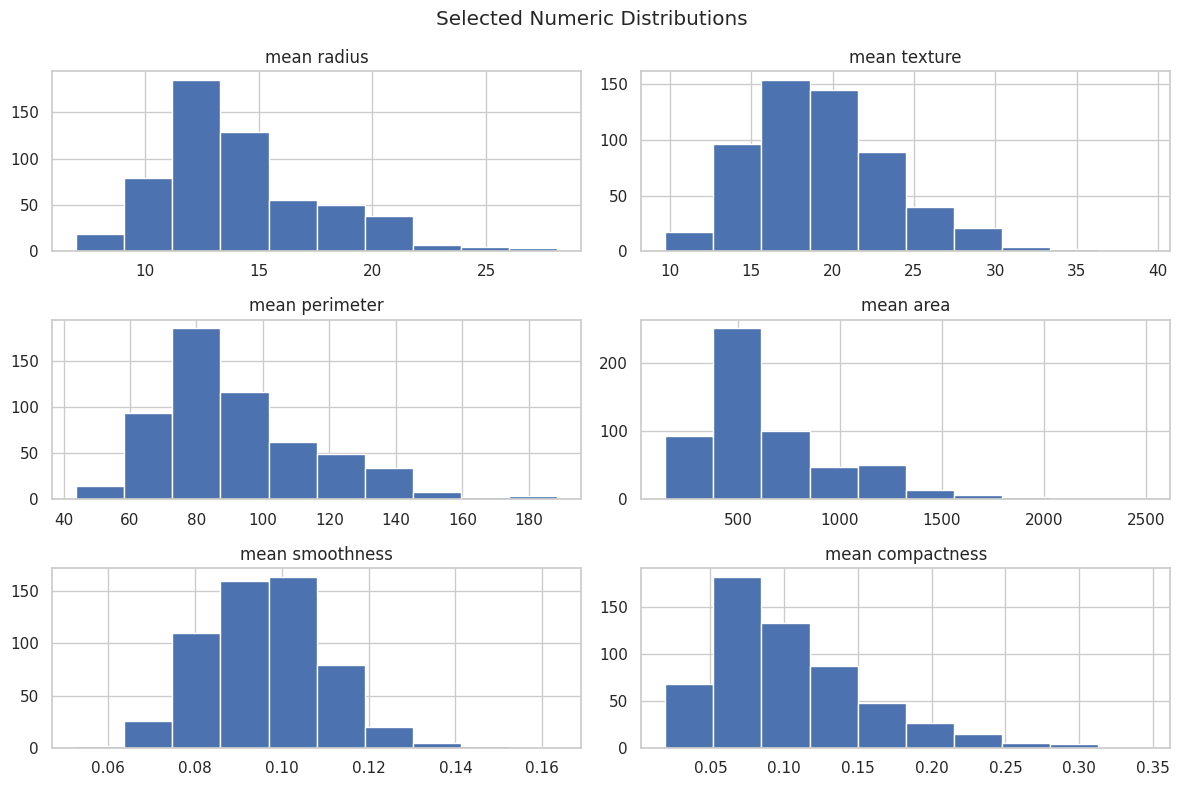

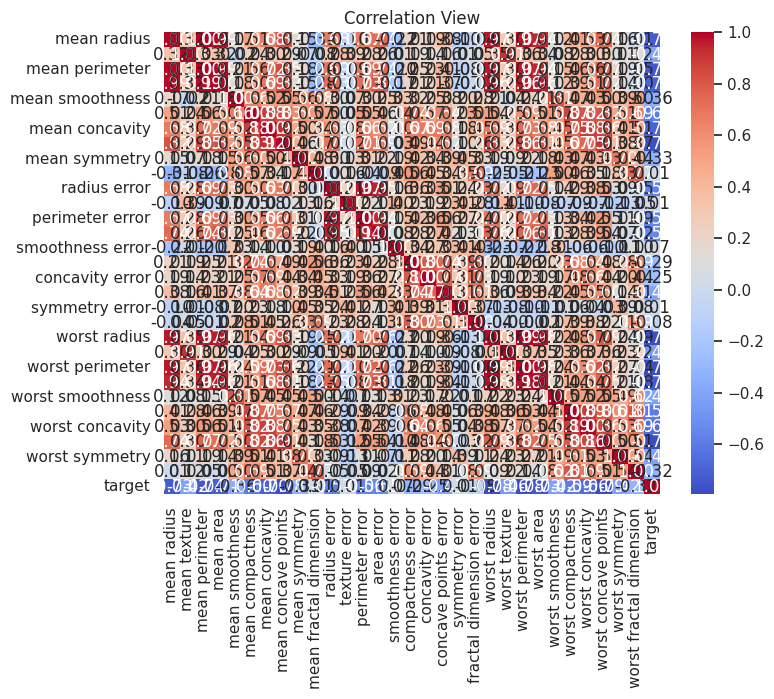

In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET]
if numeric_cols:
    df[numeric_cols[:min(6,len(numeric_cols))]].hist(figsize=(12,8))
    plt.suptitle("Selected Numeric Distributions")
    plt.tight_layout(); plt.show()
if len(numeric_cols) >= 2:
    plt.figure(figsize=(8,6))
    sns.heatmap(df[numeric_cols+[TARGET]].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation View")
    plt.show()


## Step 5 — Segregate inputs and target

**Step briefing — What / Why / Expected output**

- **What we are doing:** Create X from predictors and y from the target.
- **Why it matters:** This explicitly defines what the model is allowed to learn from.
- **What the output should tell us:** X excludes the target; y contains the classification outcome.

**Retail-banking lens:** This is the same boundary used in a banking scorecard between applicant information and the decision outcome.


In [5]:
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()
print('X shape:', X.shape, '| y shape:', y.shape)

X shape: (569, 30) | y shape: (569,)


## Step 6 — Preprocess and split the data

**Step briefing — What / Why / Expected output**

- **What we are doing:** Separate numeric and categorical features, impute missing values, encode categories and standardise numeric values when appropriate.
- **Why it matters:** Doing these operations inside a Pipeline prevents leakage from test data into training transformations.
- **What the output should tell us:** A reusable preprocessing pipeline and a stratified train/test split.

**Retail-banking lens:** Leakage prevention is a key control in regulated banking model development.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns
numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer([("num", numeric_pipe, numeric_features), ("cat", categorical_pipe, categorical_features)])
print("Training rows:", len(X_train), "Testing rows:", len(X_test))


Training rows: 455 Testing rows: 114


## Step 7 — Build the Logistic Regression model

**Step briefing — What / Why / Expected output**

- **What we are doing:** Initialise the model with explicit parameters before training.
- **Why it matters:** Model parameters control how the algorithm learns and provide a reproducible baseline.
- **What the output should tell us:** A configured estimator ready for the pipeline.

**Retail-banking lens:** A banker should be able to explain the baseline configuration before optimisation.


In [7]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000, solver="liblinear", C=1.0)
model_pipeline = Pipeline([("prep", preprocessor), ("model", model)])


## Step 8 — Train the model

**Step briefing — What / Why / Expected output**

- **What we are doing:** Fit the preprocessing + model pipeline on training data only.
- **Why it matters:** Training on the training partition preserves an honest test evaluation.
- **What the output should tell us:** A fitted pipeline.

**Retail-banking lens:** The same principle applies to training on historical banking records and evaluating on unseen customers.


In [8]:
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
print("Model trained successfully.")


Model trained successfully.


## Step 9 — Evaluate model performance

**Step briefing — What / Why / Expected output**

- **What we are doing:** Calculate accuracy, precision, recall, F1-score and ROC-AUC where possible.
- **Why it matters:** Different metrics answer different risk questions; recall matters greatly when missing a positive/negative case has business cost.
- **What the output should tell us:** A complete classification performance profile and confusion matrix.

**Retail-banking lens:** A bank should choose metrics based on the business cost of different errors, not accuracy alone.


              precision    recall  f1-score   support

           0      0.976     0.976     0.976        42
           1      0.986     0.986     0.986        72

    accuracy                          0.982       114
   macro avg      0.981     0.981     0.981       114
weighted avg      0.982     0.982     0.982       114

Accuracy : 0.9825
Precision: 0.9825
Recall   : 0.9825
F1       : 0.9825
ROC-AUC  : 0.9957


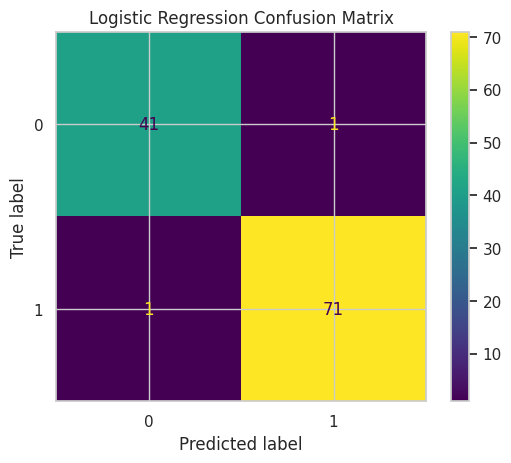

In [9]:
print(classification_report(y_test, y_pred, digits=3))
print("Accuracy :", round(accuracy_score(y_test,y_pred),4))
print("Precision:", round(precision_score(y_test,y_pred, average="weighted", zero_division=0),4))
print("Recall   :", round(recall_score(y_test,y_pred, average="weighted", zero_division=0),4))
print("F1       :", round(f1_score(y_test,y_pred, average="weighted", zero_division=0),4))
if hasattr(model_pipeline, "predict_proba") and y_test.nunique()==2:
    proba = model_pipeline.predict_proba(X_test)[:,1]
    print("ROC-AUC  :", round(roc_auc_score(y_test,proba),4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


## Step 10 — Interpret model behaviour

**Step briefing — What / Why / Expected output**

- **What we are doing:** Review feature importance or coefficients, depending on the algorithm, and connect them to the business question.
- **Why it matters:** An accurate but opaque output is harder to govern and explain.
- **What the output should tell us:** A ranked view of influential inputs when the estimator supports it.

**Retail-banking lens:** This is the bridge from a technical model to an explainable banking decision process.


In [10]:
param_grid = {"model__C":[0.1,1,10], "model__solver":["liblinear","lbfgs"]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(model_pipeline, param_grid, scoring="f1_weighted", cv=cv, n_jobs=-1)
search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)
print("Best CV score:", round(search.best_score_,4))
print("Tuned test F1:", round(f1_score(y_test, search.predict(X_test), average="weighted"),4))


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.
Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Best parameters: {'model__C': 0.1, 'model__solver': 'liblinear'}
Best CV score: 0.9824
Tuned test F1: 0.9825


## Step 11 — Hyperparameter tuning and cross-validation

**Step briefing — What / Why / Expected output**

- **What we are doing:** Search a controlled parameter grid with stratified cross-validation.
- **Why it matters:** Tuning can improve generalisation, but it must happen without leaking test information.
- **What the output should tell us:** Best parameters and cross-validated performance.

**Retail-banking lens:** This mirrors controlled model validation processes.


In [11]:
lr = model_pipeline.named_steps["model"]
if hasattr(lr, "coef_"):
    feature_names = model_pipeline.named_steps["prep"].get_feature_names_out()
    coef = pd.DataFrame({"feature":feature_names, "coefficient":lr.coef_[0]})
    display(coef.reindex(coef.coefficient.abs().sort_values(ascending=False).index).head(15))


,feature,coefficient
21,num__worst texture,-1.242
10,num__radius error,-1.088
23,num__worst area,-0.979
13,num__area error,-0.958
20,num__worst radius,-0.946
27,num__worst concave points,-0.945
28,num__worst symmetry,-0.929
26,num__worst concavity,-0.827
22,num__worst perimeter,-0.765
24,num__worst smoothness,-0.760


## Final Project Review

**What problem did I solve?**  
I built a probability-based classification workflow using logistic regression.

**What did the analysis/model learn?**  
The model estimates class membership from the available predictors, while preprocessing and cross-validation improve reliability.

**Which result matters most?**  
The most important result is the test-set F1/recall/ROC-AUC profile rather than accuracy alone.

**What limitation must be disclosed?**  
The local fallback dataset is only a validation dataset; for submission, the official assignment dataset must be supplied. Classification metrics also shift with class balance.

**What would I improve next?**  
Use the named banking dataset, examine threshold choice against business costs, and add probability calibration and fairness checks.
